# 타이타닉 데이터 탐색 (EDA)

데이터 분석 기초: **결측치 / 중복값 / 이상치** 검증하기

- 셀 실행: 셀을 클릭한 뒤 `Shift + Enter`
- 순서대로 하나씩 실행하면서 결과를 확인하세요

## 1. 데이터 불러오기

- `Passengerid` → `PassengerId`, `2urvived` → `Survived`로 컬럼명 오타 정리
- 값이 전부 0인 의미 없는 `zero*` 컬럼 19개 제거

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")

df = pd.read_csv("data/train_and_test2.csv")
df = df.rename(columns={"Passengerid": "PassengerId", "2urvived": "Survived"})
zero_cols = [c for c in df.columns if c.startswith("zero")]
df = df.drop(columns=zero_cols)
print(f"행(샘플): {df.shape[0]}개, 열(변수): {df.shape[1]}개")
df.head()

행(샘플): 1309개, 열(변수): 9개


,PassengerId,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,Survived
0,1,22.0,7.2500,0,1,0,3,2.0,0
1,2,38.0,71.2833,1,1,0,1,0.0,1
2,3,26.0,7.9250,1,0,0,3,2.0,1
3,4,35.0,53.1000,1,1,0,1,2.0,1
4,5,35.0,8.0500,0,0,0,3,2.0,0


## 2. 기본 정보 확인

`info()`: 컬럼별 데이터 타입과 결측치가 아닌 값 개수  
`describe()`: 숫자 컬럼의 평균/표준편차/사분위수 요약

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   int64  
 4   sibsp        1309 non-null   int64  
 5   Parch        1309 non-null   int64  
 6   Pclass       1309 non-null   int64  
 7   Embarked     1307 non-null   float64
 8   Survived     1309 non-null   int64  
dtypes: float64(3), int64(6)
memory usage: 92.2 KB


In [3]:
df.describe().round(2)

,PassengerId,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,Survived
count,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1307.00,1309.00
mean,655.00,29.50,33.28,0.36,0.50,0.39,2.29,1.49,0.26
std,378.02,12.91,51.74,0.48,1.04,0.87,0.84,0.81,0.44
min,1.00,0.17,0.00,0.00,0.00,0.00,1.00,0.00,0.00
25%,328.00,22.00,7.90,0.00,0.00,0.00,2.00,1.00,0.00
50%,655.00,28.00,14.45,0.00,0.00,0.00,3.00,2.00,0.00
75%,982.00,35.00,31.28,1.00,1.00,0.00,3.00,2.00,1.00
max,1309.00,80.00,512.33,1.00,8.00,9.00,3.00,2.00,1.00


## 3. 결측치 확인

`isna()`: 값이 비어있으면(결측치, NaN) True를 반환 → `sum()`으로 개수 세기

In [4]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({"결측 개수": missing, "비율(%)": missing_pct})
missing_table.sort_values("결측 개수", ascending=False)

,결측 개수,비율(%)
Embarked,2,0.15
PassengerId,0,0.00
Age,0,0.00
Sex,0,0.00
Fare,0,0.00
sibsp,0,0.00
Parch,0,0.00
Pclass,0,0.00
Survived,0,0.00


C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 52972 (\N{HANGUL SYLLABLE KEOL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 47100 (\N{HANGUL SYLLABLE REOM}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools

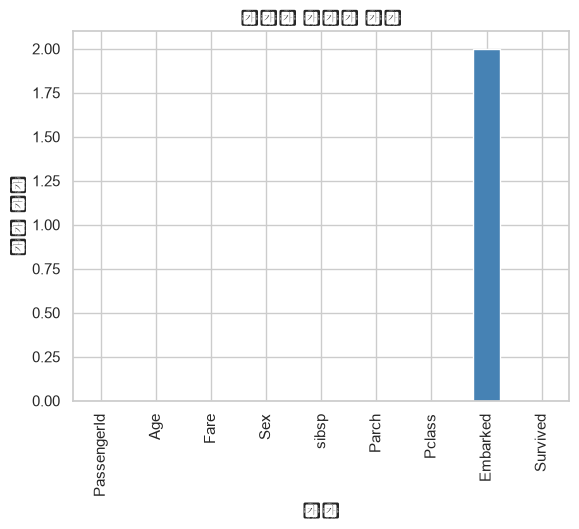

In [5]:
missing_table["결측 개수"].plot(kind="bar", color="steelblue")
plt.title("컬럼별 결측치 개수")
plt.xlabel("컬럼")
plt.ylabel("결측 개수")
plt.show()

In [6]:
df[df.isna().any(axis=1)]

,PassengerId,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,Survived
61,62,38.0,80.0,1,0,0,1,NaN,1
829,830,62.0,80.0,1,0,0,1,NaN,1


## 4. 중복값 확인

`duplicated()`: 모든 컬럼이 똑같은 행이 있으면 True

In [7]:
print("중복 행 수:", df.duplicated().sum())
print("중복 PassengerId 수:", df["PassengerId"].duplicated().sum())

중복 행 수: 0
중복 PassengerId 수: 0


## 5. 이상치 확인 (IQR 방식)

이상치 판정 기준: `Q1 - 1.5*IQR` 미만 또는 `Q3 + 1.5*IQR` 초과

In [8]:
for col in ["Age", "Fare", "sibsp", "Parch"]:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_out = int(((df[col] < lower) | (df[col] > upper)).sum())
    print(f"{col:6s}: 기준범위 [{lower:8.2f}, {upper:8.2f}], 이상치 {n_out:4d}개 ({n_out / len(df) * 100:.1f}%)")

Age   : 기준범위 [    2.50,    54.50], 이상치  101개 (7.7%)
Fare  : 기준범위 [  -27.17,    66.34], 이상치  171개 (13.1%)
sibsp : 기준범위 [   -1.50,     2.50], 이상치   57개 (4.4%)
Parch : 기준범위 [    0.00,     0.00], 이상치  307개 (23.5%)


> **주의**: `Parch`처럼 0이 대부분인 단속형(0/1/2...) 데이터는 IQR이 0이 되어 
> "1 이상이면 전부 이상치"로 잡히는 함정이 있습니다. IQR 방식은 `Age`, `Fare` 같은 연속형 데이터에서만 의미 있어요.

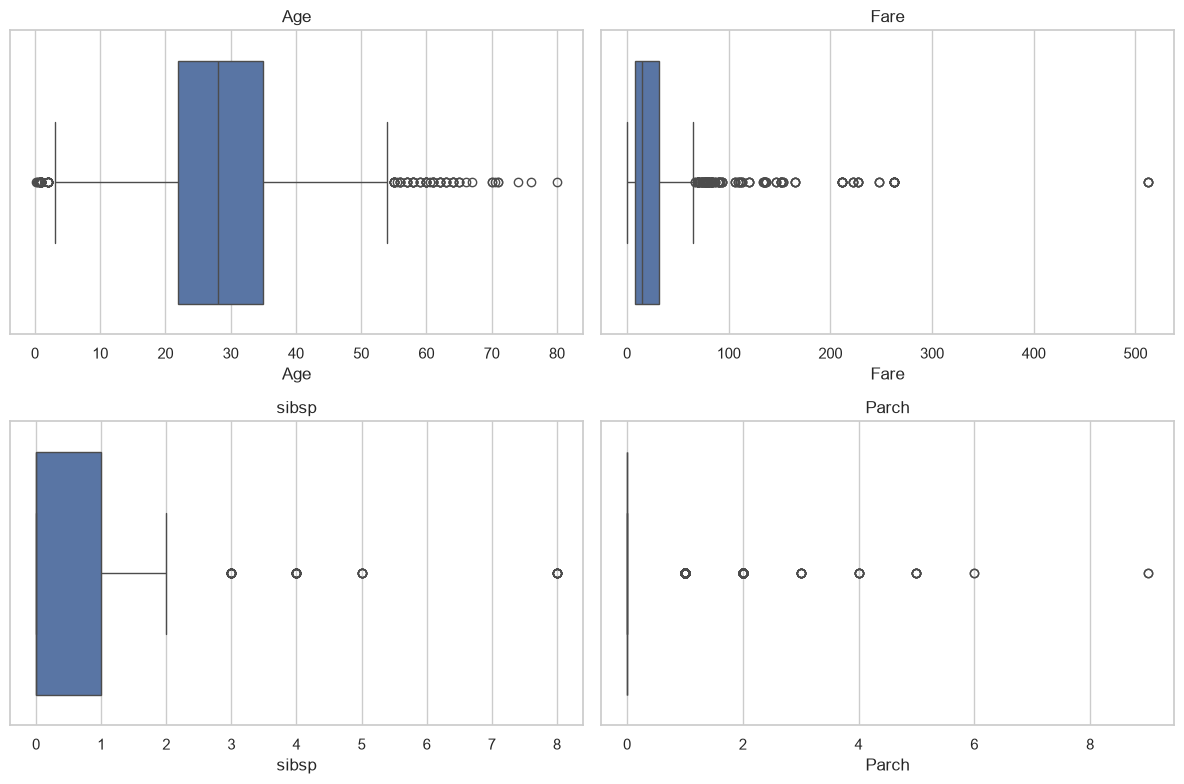

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, ["Age", "Fare", "sibsp", "Parch"]):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


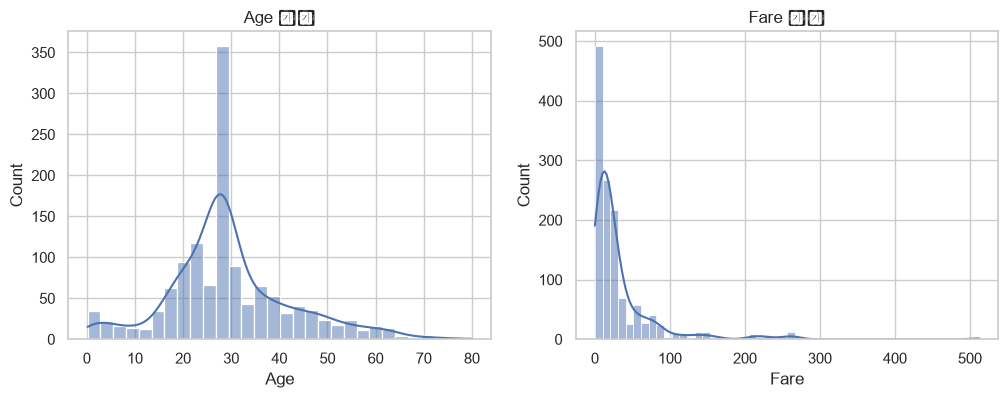

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["Age"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Age 분포")
sns.histplot(df["Fare"], bins=50, kde=True, ax=axes[1])
axes[1].set_title("Fare 분포")
plt.show()

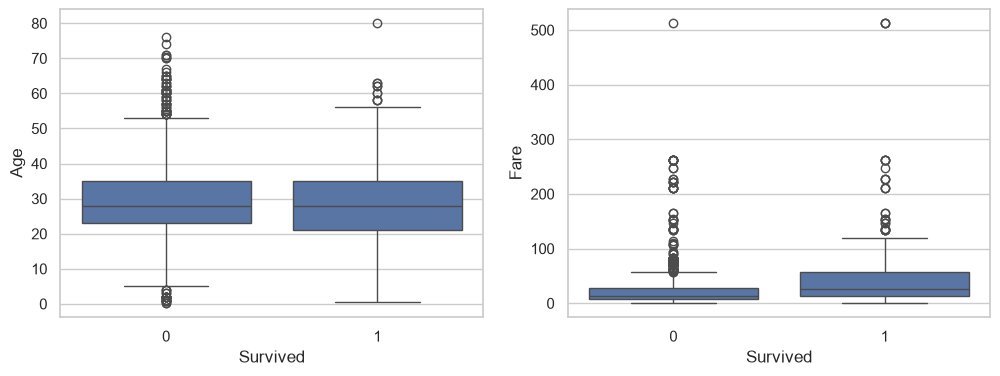

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x="Survived", y="Age", ax=axes[0])
sns.boxplot(data=df, x="Survived", y="Fare", ax=axes[1])
plt.show()

## 정리

- **결측치**: `Embarked` 2개 (PassengerId 62, 830) → 채우기 or 삭제
- **중복값**: 없음
- **이상치**: `Age` 101개, `Fare` 171개 (연속형이라 IQR 방식이 의미 있음)

다음 단계: 결측치 처리 → 범주형 변수(성별/등급/승선지) 시각화 → 생존율 분석